# **Joint single-cell DNA-RNA Data Processing (scONE-seq)**

## Description of Notebook

**Data: scONE-seq**    

-GEO accession GSE185269 (GSE185269-GPL18573_series_matrix.txt, GSE185269-GPL28038_series_matrix.txt)  
-SRA ID SRP339960 (many sequence read files)
  
**Table of Contents**

0. Initial Setup
1. Collect GEO GSE185269 Files
2. Collect Run Metadata for SRA SRP339960
3. Distinguish observations by DNA-seq/RNA-seq, cell origin
4. Download Relevant FASTQ Files
5.

# 0. Initial Setup

In [2]:
# Import Initial Packages
import os
import sys
import subprocess
import glob

import pandas as pd
import numpy as np
print(pd.__version__)   # should be ≥2.3 and <3.0
print(np.__version__)   # should be ≥1.26 and <2.1

2.2.2
2.0.2


### Install Dependencies

In [ ]:
# Install Dependencies
!pip install snapatac2-scooby

# Installing collected packages: texttable, cykhash, rustworkx, logistro, igraph, array-api-compat, pytest-timeout, pyfaidx, 
# # choreographer, kaleido, hmmlearn, anndata, macs3, snapatac2-scooby


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 713.8/713.8 kB 11.3 MB/s eta 0:00:00a 0:00:01


: 

In [3]:
!pip install -q "pandas==2.2.2" alphagenome scvi-tools scanpy anndata pysam pyranges scrublet gdown

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.0 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 41.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.9/176.9 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.1/662.1 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 61.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.0/24.0 MB 60.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install --upgrade google-cloud-bigquery



E: Unable to locate package entrez-direct
/bin/bash: line 1: fasterq-dump: command not found
/bin/bash: line 1: esearch: command not found


In [49]:
!pip install leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 25.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 48.1 MB/s eta 0:00:0000:0100:01


In [4]:
# Import relevant packages

import alphagenome
import anndata as ad
import scanpy as sc
import scvi



### Install Entrez Direct Library

In [3]:
%%bash
set -e

# Download and install Entrez Direct into $HOME/edirect
sh -c "$(curl -fsSL https://ftp.ncbi.nlm.nih.gov/entrez/entrezdirect/install-edirect.sh)"

# Show where it was installed
# ls -l $HOME/edirect


Entrez Direct has been successfully downloaded and installed.

In order to complete the configuration process, please execute the following:

  echo "export PATH=/root/edirect:\${PATH}" >> ${HOME}/.bashrc

or manually edit the PATH variable assignment in your .bashrc file.

Would you like to do that automatically now? [y/N]
Holding off, then.

To activate EDirect for this terminal session, please execute the following:

export PATH=${HOME}/edirect:${PATH}



In [4]:
# Add Entrez Direct to PATH for Python Kernel
os.environ["PATH"] = os.path.join(os.environ["HOME"], "edirect") + ":" + os.environ["PATH"]
print(os.environ["PATH"])

/root/edirect:/opt/bin:/usr/local/cuda/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin


In [5]:
# Install NCBI Entrez Direct utilities
#!apt-get install -y -qq entrez-direct 

# Verify installation
#!fasterq-dump --version
print(os.environ["PATH"])

!esearch -help | head -5

/root/edirect:/opt/bin:/usr/local/cuda/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin
esearch 25.3

Query Specification

  -db            Database name


### Install SRA Toolkit Library

In [6]:
%%bash
# Directly install SRA Toolkit from NCBI Server
set -e

cd $HOME
# Get latest Linux 64‑bit build (adjust URL if you need a different platform)
curl -L -o sratoolkit.tar.gz \
  https://ftp-trace.ncbi.nlm.nih.gov/sra/sdk/current/sratoolkit.current-ubuntu64.tar.gz

tar -xzf sratoolkit.tar.gz
ls

edirect
sratoolkit.3.4.1-ubuntu64
sratoolkit.tar.gz


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 85.0M  100 85.0M    0     0  31.1M      0  0:00:02  0:00:02 --:--:-- 31.1M


In [7]:
# Add SRA Toolkit to PATH variable

home = os.environ["HOME"]
# Find the extracted sratoolkit directory
toolkits = glob.glob(os.path.join(home, "sratoolkit.*-ubuntu64"))
assert toolkits, "No sratoolkit directory found"
sra_dir = os.path.join(toolkits[0], "bin")

os.environ["PATH"] = sra_dir + ":" + os.environ["PATH"]
print(os.environ["PATH"])

/root/sratoolkit.3.4.1-ubuntu64/bin:/root/edirect:/opt/bin:/usr/local/cuda/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin


In [3]:
# Verify installation
!fasterq-dump --version

/bin/bash: line 1: fasterq-dump: command not found


### Connect to Google Drive

In [5]:
# CONNECT TO GOOGLE DRIVE
import google.colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load files from Google Cloud BigQuery (optional)

# Authenticate Session
from google.colab import auth
auth.authenticate_user()
print('Authenticated')

# Set up GCP Project
#project_id = 'bmi-702-project' # Replace with your actual project ID
#from google.cloud import bigquery
#client = bigquery.Client(project=project_id)

Authenticated


# 1. Collect GEO GSE185269 Files

## 1a. Download GEO Data to Google Drive

In [11]:
# Download processed data (countmatrices) from GEO Project
# Claude suggested code
import subprocess

# Define output directory
output_dir = "/content/drive/MyDrive/MIT HST 506/project_data/GEO_GSE185269_files"
os.makedirs(output_dir, exist_ok=True)

# Download GEO supplementary files directly via FTP
geo_base = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE185nnn/GSE185269/suppl/"

# List available supplementary files
print("Available files:")
!curl -s {geo_base} | grep -oP '(?<=href=")[^"]+\.gz'

# Download all .gz supplementary files to the output directory
!wget -r -nd -np -A "*.gz" -P "{output_dir}" {geo_base}

# Verify download
!ls -lh "{output_dir}"

Available files:
GSE185269_10x_GBM_Gene_UMI_counts_matrix.csv.gz
GSE185269_10x_GBM_annotation.csv.gz
GSE185269_Bulk_benchmark_WGS_NormalizedCounts.txt.gz
GSE185269_Bulk_benchmark_WGS_RawCounts.txt.gz
GSE185269_Smartseq2_HCT116_RNA_gene_counts_matrix.csv.gz
GSE185269_Smartseq2_PBMC_RNA_gene_counts_matrix.csv.gz
GSE185269_scONE_HCT116_nuclei_gene_counts_expr.csv.gz
GSE185269_scONE_HCT116_whole_gene_counts_expr.csv.gz
GSE185269_scONEseq_Cellline_RNA_gene_counts_matrix.csv.gz
GSE185269_scONEseq_Cellline_scWGS_normalized_counts_matrix.txt.gz
GSE185269_scONEseq_GBM_RNA_gene_counts_matrix.csv.gz
GSE185269_scONEseq_GBM_sample_annotation.csv.gz
GSE185269_scONEseq_GBM_scWGS_mBAF_matrix.txt.gz
GSE185269_scONEseq_GBM_scWGS_normalized_counts_matrix.txt.gz
GSE185269_scONEseq_PBMC_RNA_gene_counts_matrix.csv.gz
--2026-04-20 14:47:25--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE185nnn/GSE185269/suppl/
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.13, 130.14.250.31, 2607:f220:41e:

## 1b. Read in GEO Series Matrices

In [6]:
# Folder and file paths
folder_path = '/content/drive/MyDrive/MIT HST 506/project_data'
GEO_metadata_path_1 = '/content/drive/MyDrive/MIT HST 506/project_data/GEO_GSE185269_files/GSE185269-GPL18573_series_matrix_edited.txt'
GEO_metadata_path_2 = '/content/drive/MyDrive/MIT HST 506/project_data/GEO_GSE185269_files/GSE185269-GPL28038_series_matrix_edited.txt'

GEO_series_matrix_1 = (pd.read_table(GEO_metadata_path_1)).transpose()
GEO_series_matrix_2 = (pd.read_table(GEO_metadata_path_2)).transpose()

# Make first row the column names
GEO_series_matrix_1.columns = GEO_series_matrix_1.iloc[0]
GEO_series_matrix_1.drop(GEO_series_matrix_1.index[0], inplace=True)

GEO_series_matrix_2.columns = GEO_series_matrix_2.iloc[0]
GEO_series_matrix_2.drop(GEO_series_matrix_2.index[0], inplace=True)

In [31]:
(GEO_series_matrix_2).head()

Sample_title,Sample_geo_accession,Sample_status,Sample_submission_date,Sample_last_update_date,Sample_type,Sample_channel_count,Sample_source_name_ch1,Sample_organism_ch1,Sample_characteristics_ch1,Sample_characteristics_ch1,...,Sample_instrument_model,Sample_library_selection,Sample_library_source,Sample_library_strategy,Sample_relation,Sample_relation,Sample_supplementary_file_1,series_matrix_table_begin,ID_REF,series_matrix_table_end
"HCT116, live whole cell, cell 001",GSM6682926,Public on Dec 31 2022,Oct 26 2022,Dec 31 2022,SRA,1,Colon,Homo sapiens,tissue: Colon,cell line: HCT-116,...,DNBSEQ-G400,other,transcriptomic,OTHER,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,NaN,GSM6682926,NaN
"HCT116, live whole cell, cell 002",GSM6682928,Public on Dec 31 2022,Oct 26 2022,Dec 31 2022,SRA,1,Colon,Homo sapiens,tissue: Colon,cell line: HCT-116,...,DNBSEQ-G400,other,transcriptomic,OTHER,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,NaN,GSM6682928,NaN
"HCT116, live whole cell, cell 003",GSM6682929,Public on Dec 31 2022,Oct 26 2022,Dec 31 2022,SRA,1,Colon,Homo sapiens,tissue: Colon,cell line: HCT-116,...,DNBSEQ-G400,other,transcriptomic,OTHER,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,NaN,GSM6682929,NaN
"HCT116, live whole cell, cell 004",GSM6682930,Public on Dec 31 2022,Oct 26 2022,Dec 31 2022,SRA,1,Colon,Homo sapiens,tissue: Colon,cell line: HCT-116,...,DNBSEQ-G400,other,transcriptomic,OTHER,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,NaN,GSM6682930,NaN
"HCT116, live whole cell, cell 005",GSM6682931,Public on Dec 31 2022,Oct 26 2022,Dec 31 2022,SRA,1,Colon,Homo sapiens,tissue: Colon,cell line: HCT-116,...,DNBSEQ-G400,other,transcriptomic,OTHER,BioSample: https://www.ncbi.nlm.nih.gov/biosam...,SRA: https://www.ncbi.nlm.nih.gov/sra?term=SRX...,NONE,NaN,GSM6682931,NaN


## 1c. Read in GEO Processed Count Matrices

In [7]:
Cellline_RNA_gene_counts = pd.read_csv("/content/drive/MyDrive/MIT HST 506/project_data/GEO_GSE185269_files/GSE185269_scONEseq_Cellline_RNA_gene_counts_matrix.csv.gz", compression="gzip")
# Size: 56594 rows × 336 columns
# UMI counts or read counts per gene per cell 

Cellline_scWGS_normalized_counts = pd.read_csv("/content/drive/MyDrive/MIT HST 506/project_data/GEO_GSE185269_files/GSE185269_scONEseq_Cellline_scWGS_normalized_counts_matrix.txt", sep = "\t")
# Size: 5393 rows × 216 columns
# Can treat each row as a genomic tract (bin/segment) and each column as a cell’s DNA profile.

In [25]:
(Cellline_scWGS_normalized_counts.columns)

Index(['CHR', 'START', 'END', 'feature', 'One.HUVEC.01_dedup',
       'One.HUVEC.02_dedup', 'One.HUVEC.04_dedup', 'One.HUVEC.14_dedup',
       'One.HUVEC.18_dedup', 'One.HUVEC.19_dedup',
       ...
       'C2.NPC.10H_dedup', 'C2.NPC.11B_dedup', 'C2.NPC.11C_dedup',
       'C2.NPC.11E_dedup', 'C2.NPC.11F_dedup', 'C2.NPC.11G_dedup',
       'C2.NPC.11H_dedup', 'C2.NPC.12B_dedup', 'C2.NPC.12F_dedup',
       'C2.NPC.12G_dedup'],
      dtype='object', length=216)

# 2. Collect the Run Metadata for SRA SRP339960

## 2a. Fetch the SRA metadata

In [8]:
items = os.listdir('/content/drive/MyDrive/MIT HST 506/project_data/SRA_SRP339960_files')
print(items)

['.DS_Store', 'SRP339960_runinfo_original.csv', 'SRP339960_runinfo.csv']


In [ ]:
# Fetch the Run Metadata for SRP339960 study (method using Entrez commands)

# !esearch -db sra -query SRP339960 | efetch -format runinfo > /content/drive/MyDrive/"MIT HST 506"/project_data/SRA_SRP339960_files/SRP339960_runinfo.csv

## 2b. Load the SRA metadata

In [9]:
# Folder and file paths
folder_path = '/content/drive/MyDrive/MIT HST 506/project_data'
SRA_metadata_path = '/content/drive/MyDrive/MIT HST 506/project_data/SRA_SRP339960_files/SRP339960_runinfo.csv'

SRA_metadata = pd.read_csv(SRA_metadata_path)

In [10]:
(SRA_metadata).head()

,Run,ReleaseDate,LoadDate,spots,bases,spots_with_mates,avgLength,size_MB,AssemblyName,download_path,...,Affection_Status,Analyte_Type,Histological_Type,Body_Site,CenterName,Submission,dbgap_study_accession,Consent,RunHash,ReadHash
0,SRR16195160,2022-12-31 00:17:52,2021-10-04 17:05:27,442928,63422994,442928,143,24,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,7F5445FC0D80D205A571A73A84A9813E,4624C3F8688710092CB2E423492A75BB
1,SRR16195159,2022-12-31 00:17:52,2021-10-04 17:05:27,289373,41434581,289373,143,16,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,3068B3F5E9C0C2F9A3A972C5C4889108,D629EB7BAA322A8F5F0350F4B06C4896
2,SRR16195158,2022-12-31 00:17:52,2021-10-04 17:05:28,330976,47390825,330976,143,18,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,60F618611CE76F02E8C973729976403F,55E10B7273275C5C5823327EE077CD98
3,SRR16195157,2022-12-31 00:17:52,2021-10-04 17:05:44,1433760,205376026,1433760,143,82,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,D152661CFEAA7B2875DAC9D5CF5E706E,27458B2217D5EA134A6F093CC0330A1F
4,SRR16195156,2022-12-31 00:17:52,2021-10-04 17:05:46,1249934,179029075,1249934,143,72,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,D8755140C9235842B99A1295DAEE5CAC,9C8F0FA05CE1662288524F1170EB7260


In [8]:
# Load and inspect

runinfo = pd.read_csv("/content/drive/MyDrive/MIT HST 506/project_data/SRA_SRP339960_files/SRP339960_runinfo.csv")
print(runinfo.shape)
print(runinfo.columns.tolist())
runinfo.head(10)

(621, 47)
['Run', 'ReleaseDate', 'LoadDate', 'spots', 'bases', 'spots_with_mates', 'avgLength', 'size_MB', 'AssemblyName', 'download_path', 'Experiment', 'LibraryName', 'LibraryStrategy', 'LibrarySelection', 'LibrarySource', 'LibraryLayout', 'InsertSize', 'InsertDev', 'Platform', 'Model', 'SRAStudy', 'BioProject', 'Study_Pubmed_id', 'ProjectID', 'Sample', 'BioSample', 'SampleType', 'TaxID', 'ScientificName', 'SampleName', 'g1k_pop_code', 'source', 'g1k_analysis_group', 'Subject_ID', 'Sex', 'Disease', 'Tumor', 'Affection_Status', 'Analyte_Type', 'Histological_Type', 'Body_Site', 'CenterName', 'Submission', 'dbgap_study_accession', 'Consent', 'RunHash', 'ReadHash']


,Run,ReleaseDate,LoadDate,spots,bases,spots_with_mates,avgLength,size_MB,AssemblyName,download_path,...,Affection_Status,Analyte_Type,Histological_Type,Body_Site,CenterName,Submission,dbgap_study_accession,Consent,RunHash,ReadHash
0,SRR16195160,2022-12-31 00:17:52,2021-10-04 17:05:27,442928,63422994,442928,143,24,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,7F5445FC0D80D205A571A73A84A9813E,4624C3F8688710092CB2E423492A75BB
1,SRR16195159,2022-12-31 00:17:52,2021-10-04 17:05:27,289373,41434581,289373,143,16,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,3068B3F5E9C0C2F9A3A972C5C4889108,D629EB7BAA322A8F5F0350F4B06C4896
2,SRR16195158,2022-12-31 00:17:52,2021-10-04 17:05:28,330976,47390825,330976,143,18,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,60F618611CE76F02E8C973729976403F,55E10B7273275C5C5823327EE077CD98
3,SRR16195157,2022-12-31 00:17:52,2021-10-04 17:05:44,1433760,205376026,1433760,143,82,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,D152661CFEAA7B2875DAC9D5CF5E706E,27458B2217D5EA134A6F093CC0330A1F
4,SRR16195156,2022-12-31 00:17:52,2021-10-04 17:05:46,1249934,179029075,1249934,143,72,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,D8755140C9235842B99A1295DAEE5CAC,9C8F0FA05CE1662288524F1170EB7260
5,SRR16195155,2022-12-31 00:17:52,2021-10-04 17:05:48,1249873,179028128,1249873,143,72,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,A030D8031AD0F81019F804F0DDBFC276,48036FDD9DC94429BC9BDA44B2A4ED3C
6,SRR16195154,2022-12-31 00:17:52,2021-10-04 17:05:45,1229207,176079810,1229207,143,70,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,E475C90208DE4129E051CF73D9EAFA98,2A7F69DBCE6B811F488FD7450B0D53C6
7,SRR16195153,2022-12-31 00:17:52,2021-10-04 17:05:41,1024753,146792703,1024753,143,59,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,67DA2996604182344AD26D7EE1AF14B5,5FAA152A579A111C612A94EFD9F3606A
8,SRR16195152,2022-12-31 00:17:52,2021-10-04 17:05:36,1015576,145446512,1015576,143,58,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,CF0AEF250FF730207A569BF366135B43,0C2F1867F5C907379937020DB94ABDFA
9,SRR16195151,2022-12-31 00:17:52,2021-10-04 17:05:36,713817,102235095,713817,143,41,NaN,https://sra-downloadb.be-md.ncbi.nlm.nih.gov/s...,...,NaN,NaN,NaN,NaN,"ANGELA WU LAB, LIFS, HKUST",SRA1305581,NaN,public,263EBD86D10A955037FE225C970E5AB5,E72940FD9479ABFBDC9A96D6E4B8E0F2


# 3. Distinguish observations by DNA-seq/RNA-seq, cell origin

## 3a. Separate scDNA and scRNA Runs

In [27]:
# Separate WGS (DNA) and RNA-seq runs
dna_runs = runinfo[runinfo['LibraryStrategy'] == 'OTHER']['Run'].tolist()
rna_runs = runinfo[runinfo['LibraryStrategy'] == 'RNA-Seq']['Run'].tolist()

print(f"DNA (WGS) runs: {len(dna_runs)}")
print(f"RNA-seq runs:   {len(rna_runs)}")
print("\nDNA runs:", dna_runs[:5])
print("RNA runs:", rna_runs[:5])

DNA (WGS) runs: 525
RNA-seq runs:   96

DNA runs: ['SRR16195157', 'SRR16195156', 'SRR16195155', 'SRR16195154', 'SRR16195153']
RNA runs: ['SRR16195160', 'SRR16195159', 'SRR16195158', 'SRR16195109', 'SRR16195108']


In [ ]:
# Sample Name, Library Name, BioSample
print(f"Number of unique Runs: {len((runinfo['Run']).unique())}") #621
print(f"Number of unique Sample Names: {len((runinfo['SampleName']).unique())}") #621
print(f"Number of unique Library Names: {len((runinfo['LibraryName']).unique())}") #621
print(f"Number of unique BioSamples: {len((runinfo['BioSample']).unique())}") #621
print(f"Number of unique Experiments: {len((runinfo['Experiment']).unique())}") #621
print(f"Number of unique Samples: {len((runinfo['Sample']).unique())}") #621


Number of unique Runs: 621
Number of unique Sample Names: 621
Number of unique Library Names: 621
Number of unique BioSamples: 621
Number of unique Experiments: 621
Number of unique Samples: 621


In [34]:
dna_len = len(dna_runs)        # 525
rna_len = len(rna_runs)        # 96

# Pad rna_runs with NaN up to dna_len
rna_runs_padded = rna_runs + [np.nan] * (dna_len - rna_len)

In [36]:
len(rna_runs_padded)

525

In [38]:

df_runs = pd.DataFrame({
    "DNA_Samples": dna_runs,
    "RNA_Samples": rna_runs_padded
})

df_runs.to_csv("/content/drive/MyDrive/MIT HST 506/project_data/DNA_RNA_samples.csv")

## 3b. Preprocess GEO Series Matrix 1 (GPL18573)

In [ ]:
GEO_series_matrix_1_processed = GEO_series_matrix_1.copy() #431 x 48
# IDEA: join SRA metadata and GEO series matrix 1 on their unique SampleName/Sample_geo_accession.

# Rename duplicate columns
from collections import Counter

cols = list(GEO_series_matrix_1_processed.columns)
seen = Counter()
new_cols = []

# keep the first column name exactly
new_cols.append(cols[0])
seen[cols[0]] += 1

# process the rest, de‑duplicating as needed
for c in cols[1:]:
    seen[c] += 1
    if seen[c] == 1:
        new_cols.append(c)
    else:
        new_cols.append(f"{c}_{seen[c]}")

GEO_series_matrix_1_processed.columns = new_cols

GEO_series_matrix_1_processed.index.name = 'Sample_title'
GEO_series_matrix_1_processed = GEO_series_matrix_1_processed.reset_index()

In [73]:
# GEO series matrix 1: 431 rows x 49 columns

# Variables to keep: 
# Sample_title, Sample_geo_accession, Sample_source_name_ch1, Sample_library_selection, Sample_library_source
# Sample_library_strategy, Sample_characteristics_ch1_2, Sample_description, Sample_description_2, Sample_platform_id
# Sample_instrument_model, 

# Variables to remove: 
# Sample_status, Sample_submission_date, Sample_last_update, Sample_type, Sample_channel_count
# Sample_organism_ch1, Sample_characteristics_ch1, Sample_instrument_model, Sample_relation, Sample_relation_2
# Sample_supplementary_file_1, series_matrix_table_begin, ID_REF, series_matrix_table_end
# Sample_characteristics_ch1_2, Sample_growth_protocol_ch1, Sample_molecule_ch1, Sample_extract_protocol_ch1, 
# Sample_extract_protocol_ch1_2, Sample_taxid_ch1
# 'Sample_data_processing', 'Sample_data_processing_2', 'Sample_data_processing_3', 'Sample_data_processing_4', 'Sample_data_processing_5', 
# 'Sample_data_processing_6','Sample_data_processing_7', 'Sample_data_processing_8', 'Sample_data_processing_9', 'Sample_data_processing_10',
# 'Sample_contact_name', 'Sample_contact_email', 'Sample_contact_laboratory', 'Sample_contact_department', 'Sample_contact_institute', 
# 'Sample_contact_address','Sample_contact_city', 'Sample_contact_zip/postal_code', 'Sample_contact_country', 'Sample_data_row_count',

vars_to_keep = [
"Sample_title", "Sample_geo_accession", "Sample_source_name_ch1", "Sample_library_selection", 
"Sample_library_source", "Sample_library_strategy", "Sample_characteristics_ch1_2", "Sample_description",
 "Sample_description_2", "Sample_platform_id", "Sample_instrument_model"
]

GEO_series_matrix_1_processed = GEO_series_matrix_1_processed[vars_to_keep]

In [ ]:
# Fix sample_description column
GEO_series_matrix_1_processed["Sample_description"] = GEO_series_matrix_1_processed["Sample_description"].replace("RNA+DNA", np.nan)

# New column with the cell info from whichever column is non‑NaN
GEO_series_matrix_1_processed["Sample_description"] = GEO_series_matrix_1_processed["Sample_description"].fillna(
    GEO_series_matrix_1_processed["Sample_description_2"]
)

# Remove unnecessary columns
GEO_series_matrix_1_processed = GEO_series_matrix_1_processed.drop(columns=["Sample_description_2"])

# (GEO_series_matrix_1_processed["Sample_characteristics_ch1_2"]) #431 unique values

In [ ]:
GEO_series_matrix_1_processed.to_csv("/content/drive/MyDrive/MIT HST 506/project_data/GSE185269-GPL18573_series_matrix_processed.csv")

## 3c. Preprocess GEO Series Matrix 2 (GPL18573)

In [ ]:
# GEO series matrix 2: 47 columns
GEO_series_matrix_2_processed = GEO_series_matrix_2.copy() 

# Rename duplicate columns
from collections import Counter

cols = list(GEO_series_matrix_2_processed.columns)
seen = Counter()
new_cols = []

# keep the first column name exactly
new_cols.append(cols[0])
seen[cols[0]] += 1

# process the rest, de‑duplicating as needed
for c in cols[1:]:
    seen[c] += 1
    if seen[c] == 1:
        new_cols.append(c)
    else:
        new_cols.append(f"{c}_{seen[c]}")

GEO_series_matrix_2_processed.columns = new_cols

GEO_series_matrix_2_processed.index.name = 'Sample_title'
GEO_series_matrix_2_processed = GEO_series_matrix_2_processed.reset_index()

In [ ]:
# GEO series matrix 2: #190 rows x 47 columns

# Variables to keep: 
# Sample_title, Sample_geo_accession, Sample_characteristics_ch1_2, Sample_description, Sample_platform_id
# Sample_library_selection, Sample_library_source, Sample_library_strategy, Sample_instrument_model


# Variables to remove: 
# Sample_status, Sample_submission_date, Sample_last_update, Sample_type, Sample_channel_count
# Sample_organism_ch1, Sample_characteristics_ch1, Sample_instrument_model, Sample_relation, Sample_relation_2
# Sample_supplementary_file_1, series_matrix_table_begin, ID_REF, series_matrix_table_end
# Sample_growth_protocol_ch1, Sample_molecule_ch1, Sample_extract_protocol_ch1, 
# Sample_extract_protocol_ch1_2, Sample_taxid_ch1, Sample_molecule_ch1, Sample_source_name_ch1
# 'Sample_data_processing', 'Sample_data_processing_2', 'Sample_data_processing_3', 'Sample_data_processing_4', 'Sample_data_processing_5', 
# 'Sample_data_processing_6','Sample_data_processing_7', 'Sample_data_processing_8', 'Sample_data_processing_9', 'Sample_data_processing_10',
# 'Sample_contact_name', 'Sample_contact_email', 'Sample_contact_laboratory', 'Sample_contact_department', 'Sample_contact_institute', 
# 'Sample_contact_address','Sample_contact_city', 'Sample_contact_zip/postal_code', 'Sample_contact_country', 'Sample_data_row_count',


vars_to_keep_2 = [
"Sample_title", "Sample_geo_accession", "Sample_characteristics_ch1_2", "Sample_description", "Sample_platform_id",
"Sample_library_selection", "Sample_library_source", "Sample_library_strategy", "Sample_instrument_model"
]

GEO_series_matrix_2_processed = GEO_series_matrix_2_processed[vars_to_keep_2]

GEO_series_matrix_2_processed["Sample_description"] = GEO_series_matrix_2_processed["Sample_title"]

# GEO_series_matrix_2_processed.head(5)

In [105]:
GEO_series_matrix_2_processed.to_csv("/content/drive/MyDrive/MIT HST 506/project_data/GSE185269-GPL28038_series_matrix_processed.csv")

## 3d. Concatenate GEO Series Matrices

In [ ]:
#GEO_series_matrix_1_processed.head()

# Rename Sample_source_name_ch1 to Sample_cell_line
GEO_series_matrix_1_processed.rename(columns={'Sample_source_name_ch1': 'Sample_cell_line'}, inplace=True)

# Rename Sample_description to Sample_cell_description
GEO_series_matrix_1_processed.rename(columns={'Sample_description': 'Sample_cell_description'}, inplace=True)

# Remove Sample_characteristics_ch1_2
GEO_series_matrix_1_processed = GEO_series_matrix_1_processed.drop(columns=["Sample_characteristics_ch1_2"])

,Sample_title,Sample_geo_accession,Sample_cell_line,Sample_library_selection,Sample_library_source,Sample_library_strategy,Sample_cell_description,Sample_platform_id,Sample_instrument_model
0,Smart-HCT-01,GSM5609425,HCT116 cell line,cDNA,transcriptomic,RNA-Seq,HCT116 single cell 001,GPL18573,Illumina NextSeq 500
1,Smart-HCT-02,GSM5609426,HCT116 cell line,cDNA,transcriptomic,RNA-Seq,HCT116 single cell 002,GPL18573,Illumina NextSeq 500
2,Smart-HCT-03,GSM5609427,HCT116 cell line,cDNA,transcriptomic,RNA-Seq,HCT116 single cell 003,GPL18573,Illumina NextSeq 500
3,Smart-HCT-04,GSM5609428,HCT116 cell line,cDNA,transcriptomic,RNA-Seq,HCT116 single cell 004,GPL18573,Illumina NextSeq 500
4,Smart-HCT-05,GSM5609429,HCT116 cell line,cDNA,transcriptomic,RNA-Seq,HCT116 single cell 005,GPL18573,Illumina NextSeq 500
...,...,...,...,...,...,...,...,...,...
426,NPC43 scONEseq 166,GSM5609851,NPC43 cell line,other,transcriptomic,OTHER,NPC single cell 166,GPL18573,Illumina NextSeq 500
427,NPC43 scONEseq 167,GSM5609852,NPC43 cell line,other,transcriptomic,OTHER,NPC single cell 167,GPL18573,Illumina NextSeq 500
428,NPC43 scONEseq 168,GSM5609853,NPC43 cell line,other,transcriptomic,OTHER,NPC single cell 168,GPL18573,Illumina NextSeq 500
429,NPC43 scONEseq 169,GSM5609854,NPC43 cell line,other,transcriptomic,OTHER,NPC single cell 169,GPL18573,Illumina NextSeq 500


In [ ]:
# Rename Sample_characteristics_ch1_2 to Sample_cell_line
GEO_series_matrix_2_processed.rename(columns={'Sample_characteristics_ch1_2': 'Sample_cell_line'}, inplace=True)

# Rename Sample_description to Sample_cell_description
GEO_series_matrix_2_processed.rename(columns={'Sample_description': 'Sample_cell_description'}, inplace=True)


/tmp/ipykernel_1516/2529234801.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  GEO_series_matrix_2_processed.rename(columns={'Sample_characteristics_ch1_2': 'Sample_cell_line'}, inplace=True)
/tmp/ipykernel_1516/2529234801.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  GEO_series_matrix_2_processed.rename(columns={'Sample_description': 'Sample_cell_description'}, inplace=True)


In [ ]:
GEO_series_matrix_combined = pd.concat([GEO_series_matrix_1_processed, GEO_series_matrix_2_processed], ignore_index = True)
GEO_series_matrix_combined.to_csv("/content/drive/MyDrive/MIT HST 506/project_data/GEO_series_matrix_combined.csv")


## 3e. Join GEO series metadata with SRA Metadata

In [ ]:
# New df name: full_metadata
# Join runinfo and GEO_series_matrix_combined: runinfo["SampleName"] and GEO_series_matrix_combined["Sample_geo_accession"]
# Use left merge to join matrices
#GEO_series_matrix_combined["Sample_geo_accession"]

geo_meta = GEO_series_matrix_combined.rename(
    columns={"Sample_geo_accession": "SampleName"}
)

full_metadata = runinfo.merge(
geo_meta, 
on = "SampleName",
how = "left"
)

full_metadata.to_csv("/content/drive/MyDrive/MIT HST 506/project_data/full_metadata.csv") # 621 rows × 55 columns


In [ ]:
cols = ["Run", "LibraryName", "LibraryStrategy", "LibrarySelection", "SampleName", "Sample_title", "Sample_cell_line", "Sample_library_selection", "Sample_library_source", "Sample_library_strategy", "Sample_cell_description", "Sample_platform_id", "Sample_instrument_model"]


metadata_subset = full_metadata[cols]

metadata_subset.to_csv("/content/drive/MyDrive/MIT HST 506/project_data/metadata_subset.csv")


## 3f. Label runs by RNA/DNA sequencing and cell number

In [136]:
df = full_metadata.copy()

# For convenience, give it a short name
df["cell_id"] = df["Sample_cell_description"].str.strip()

In [ ]:
# Identify RNA vs DNA rows
rna = df[df["LibraryStrategy"] == "RNA-Seq"].copy()
dna = df[df["LibraryStrategy"] != "RNA-Seq"].copy()

#rna["Sample_title"].value_counts()
#dna["Sample_title"].value_counts()
#rna["Sample_platform_id"].value_counts()
#dna["Sample_platform_id"].value_counts()

In [172]:

#df["cell_id"].unique()
#with pd.option_context('display.max_colwidth', None, 'display.max_rows', None):
#    print(df.loc[:,["cell_id", "LibraryStrategy", "Sample_platform_id"]])

#print(df["LibraryStrategy"])

In [202]:
# Normalize biological cells with different strings; focus on HCT116 first

# Pull HCT116 rows:
hct = df[df["Sample_cell_description"].str.contains("HCT116", na=False)].copy()

# Extract a normalized cell number
import re

def extract_cell_num(desc):
    if pd.isna(desc):
        return None
    m = re.search(r'(\d+)\s*$', desc)  # last integer at end of string
    return int(m.group(1)) if m else None

hct["cell_num"] = hct["Sample_cell_description"].apply(extract_cell_num)


# RNA: Smart-Seq
hct_rna = hct[hct["LibraryStrategy"] == "RNA-Seq"].copy()

# DNA: scONE on DNBSEQ (GPL28038)
hct_dna = hct[(hct["LibraryStrategy"] != "RNA-Seq") &
              (hct["Sample_platform_id"] == "GPL28038")].copy()

In [203]:
# Split DNA into live whole cell and extracted nuclei
dna_live   = hct_dna[hct_dna["Sample_cell_description"].str.contains("live whole cell", na=False)].copy()
dna_nuclei = hct_dna[hct_dna["Sample_cell_description"].str.contains("extracted nuclei", na=False)].copy()

# Make a preferred DNA table: live whole cell first, then nuclei as fallback
# one DNA run per (cell_num, type)
dna_live_min = dna_live.groupby("cell_num")["Run"].first().reset_index().rename(columns={"Run": "dna_run_live"})
dna_nuclei_min = dna_nuclei.groupby("cell_num")["Run"].first().reset_index().rename(columns={"Run": "dna_run_nuclei"})

# Merge them
dna_pref = pd.merge(dna_live_min, dna_nuclei_min, on="cell_num", how="outer")

# Select a single DNA run per cell_num
def choose_dna(row):
    if pd.notna(row["dna_run_live"]):
        return row["dna_run_live"]
    else:
        return row["dna_run_nuclei"]

dna_pref["dna_run"] = dna_pref.apply(choose_dna, axis=1)

# Keep only rows where we have some DNA
dna_pref = dna_pref[pd.notna(dna_pref["dna_run"])]
dna_pref = dna_pref[["cell_num", "dna_run"]]

In [ ]:
# Build combined RNA-DNA table
rna_min = hct_rna.groupby("cell_num")["Run"].first().reset_index().rename(columns={"Run": "rna_run"})

pairs = pd.merge(rna_min, dna_pref, on="cell_num", how="inner")

#96 pairs
#len(pairs)

pairs.to_csv("/content/drive/MyDrive/MIT HST 506/project_data/DNA_RNA_pairs.csv")


In [ ]:
# Build combined RNA-DNA table, only include DNA from live whole cells
dna_only_live = dna_live_min.rename(columns={"Run": "dna_run"})
pairs_live = pd.merge(rna_min, dna_only_live, on="cell_num", how="inner")

#type(pairs_live) #92
pairs_live.to_csv("/content/drive/MyDrive/MIT HST 506/project_data/DNA_RNA_pairs_live_whole_cell.csv")

# 4. Download FASTQ Files

## 4a. Download a small subset first to test

In [ ]:
# Define base path on Google Drive
base_path = "/content/drive/MyDrive/MIT HST 506/project_data/FASTQ_files"

os.makedirs(f"{base_path}/dna", exist_ok=True)
os.makedirs(f"{base_path}/rna", exist_ok=True)

# Test with first DNA run
test_dna = dna_runs[0]
!fasterq-dump {test_dna} --split-files --outdir "{base_path}/dna" --threads 4
!gzip "{base_path}/dna/{test_dna}"*.fastq

# Test with first RNA run
test_rna = rna_runs[0]
!fasterq-dump {test_rna} --split-files --outdir "{base_path}/rna" --threads 4
!gzip "{base_path}/rna/{test_rna}"*.fastq

!ls -lh "{base_path}/dna/"
!ls -lh "{base_path}/rna/"

spots read      : 1,433,760
reads read      : 2,867,520
reads written   : 2,867,520
spots read      : 442,928
reads read      : 885,856
reads written   : 885,856
total 127M
-rw------- 1 root root 64M Apr 20 03:06 SRR16195157_1.fastq.gz
-rw------- 1 root root 63M Apr 20 03:06 SRR16195157_2.fastq.gz
total 40M
-rw------- 1 root root 20M Apr 20 03:07 SRR16195160_1.fastq.gz
-rw------- 1 root root 20M Apr 20 03:07 SRR16195160_2.fastq.gz


# 5. Generate Cell Type-Specific RNA-seq Embeddings using scVI

## 5a. Quality Control and Preprocessing of scRNA-seq

In [ ]:
# LIST FILES IN DIRECTORY
geo_dir = "/content/drive/MyDrive/MIT HST 506/project_data/GEO_GSE185269_files"
for f in sorted(os.listdir(geo_dir)):
    size = os.path.getsize(os.path.join(geo_dir, f))
    print(f"{f:60s}  {size/1024:.1f} KB")

In [62]:

from anndata import AnnData

# GSE185269_scONEseq_Cellline_RNA_gene_counts_matrix.csv.gz
# Load CSV object
csv_path = "/content/drive/MyDrive/MIT HST 506/project_data/GEO_GSE185269_files/GSE185269_scONEseq_Cellline_RNA_gene_counts_matrix.csv.gz"
df = pd.read_csv(csv_path, index_col=0, compression = "gzip") # Size: 56594 x 335

In [63]:
df.shape

(56594, 335)

In [22]:
# Load Ann Data Object
#import scanpy as sc
#import scvi
#import anndata as ad
from anndata import AnnData

# Load CSV object
csv_path = "/content/drive/MyDrive/MIT HST 506/project_data/GEO_GSE185269_files/GSE185269_scONEseq_Cellline_RNA_gene_counts_matrix.csv.gz"
df = pd.read_csv(csv_path, index_col=0, compression = "gzip") # Size: 56594 x 335

# Create AnnData Object
adata = AnnData(X=df.T)   # cells × genes
adata.var_names = df.index   # gene names
adata.obs_names = df.columns # cell IDs

h5ad_path = "/content/drive/MyDrive/MIT HST 506/project_data/GEO_GSE185269_files/GSE185269_scONEseq_Cellline_RNA_gene_counts_matrix.h5ad"
adata.write(h5ad_path)


In [70]:
# Can reload AnnData Object
import scanpy as sc
#import scvi
#import anndata as ad
from anndata import AnnData

# Load the RNA count matrix (cells × genes)
h5ad_path = "/content/drive/MyDrive/MIT HST 506/project_data/GEO_GSE185269_files/GSE185269_scONEseq_Cellline_RNA_gene_counts_matrix.h5ad"
adata = sc.read_h5ad(h5ad_path)

adata_original = adata.copy()

In [68]:
# ORIGINAL DATA SIZE

print(f"Cells: {adata_original.n_obs}") #335 cells
print(f"Genes: {adata_original.n_vars}") #56594 genes
print(adata_original)


Cells: 335
Genes: 56594
AnnData object with n_obs × n_vars = 335 × 56594


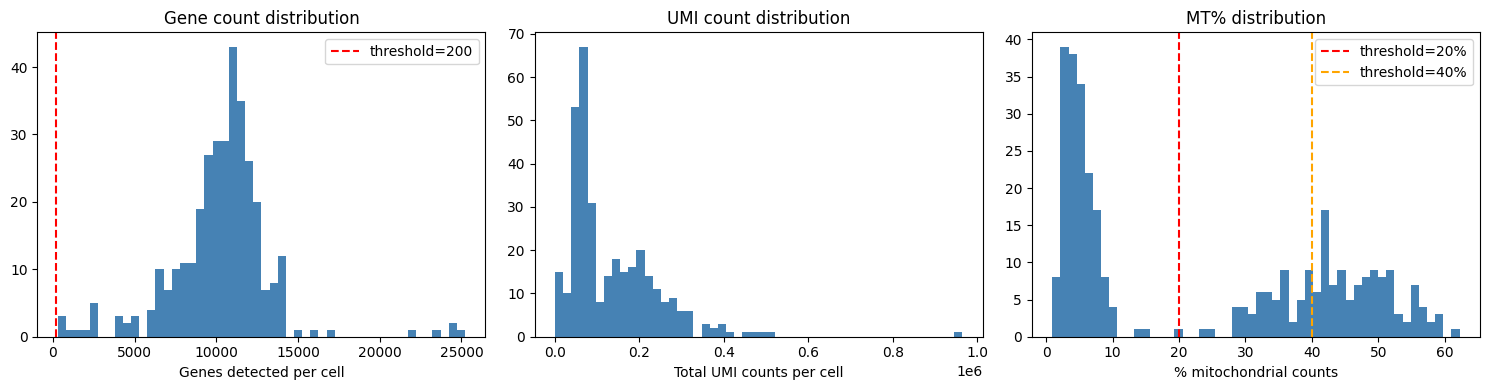


n_genes_by_counts:
  min=289.0, median=10671.0, max=25222.0
  10th pct=6860.8, 90th pct=12854.8

total_counts:
  min=392.1, median=85699.4, max=964756.2
  10th pct=44577.5, 90th pct=271630.5

pct_counts_mt:
  min=0.9, median=10.0, max=62.2
  10th pct=3.1, 90th pct=51.0


In [69]:
# Visualize original data distribution
import matplotlib.pyplot as plt
import scanpy as sc


# Annotate mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

# Plot distributions of all three key QC metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(adata.obs['n_genes_by_counts'], bins=50, color='steelblue')
axes[0].set_xlabel('Genes detected per cell')
axes[0].set_title('Gene count distribution')
axes[0].axvline(200, color='red', linestyle='--', label='threshold=200')
axes[0].legend()

axes[1].hist(adata.obs['total_counts'], bins=50, color='steelblue')
axes[1].set_xlabel('Total UMI counts per cell')
axes[1].set_title('UMI count distribution')

axes[2].hist(adata.obs['pct_counts_mt'], bins=50, color='steelblue')
axes[2].set_xlabel('% mitochondrial counts')
axes[2].set_title('MT% distribution')
axes[2].axvline(20, color='red', linestyle='--', label='threshold=20%')
axes[2].axvline(40, color='orange', linestyle='--', label='threshold=40%')
axes[2].legend()

plt.tight_layout()
plt.show()

# Print exact percentile values to inform threshold choice
import numpy as np
for metric in ['n_genes_by_counts', 'total_counts', 'pct_counts_mt']:
    vals = adata.obs[metric]
    print(f"\n{metric}:")
    print(f"  min={vals.min():.1f}, median={vals.median():.1f}, "
          f"max={vals.max():.1f}")
    print(f"  10th pct={np.percentile(vals,10):.1f}, "
          f"90th pct={np.percentile(vals,90):.1f}")

In [71]:
# Claude suggested QC Pipeline:
import numpy as np
from scipy.stats import median_abs_deviation
import scanpy as sc

adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

print(f"Starting cells: {adata.n_obs}")

# --- Filter 1: Remove cells with very few genes (true empty droplets/debris) ---
# Your min is 289, median is 10671 — only remove extreme low outliers
min_gene_threshold = 500   # safely below your 10th percentile of 6860
adata = adata[adata.obs['n_genes_by_counts'] >= min_gene_threshold].copy()
print(f"After gene filter (>={min_gene_threshold} genes): {adata.n_obs} cells")

# --- Filter 2: MT% — use MAD-based upper bound, not a fixed threshold ---
# Given your distribution, a fixed threshold is inappropriate
mt_vals = adata.obs['pct_counts_mt'].values
mt_median = np.median(mt_vals)
mt_mad = median_abs_deviation(mt_vals)
mt_upper = mt_median + 3 * mt_mad    # adaptive upper bound

print(f"\nMT% median: {mt_median:.1f}%, MAD: {mt_mad:.1f}%")
print(f"Adaptive MT upper threshold (median + 3 MAD): {mt_upper:.1f}%")

adata = adata[adata.obs['pct_counts_mt'] <= mt_upper].copy()
print(f"After adaptive MT filter (<={mt_upper:.1f}%): {adata.n_obs} cells")

# --- Filter 3: Remove genes detected in fewer than 3 cells ---
sc.pp.filter_genes(adata, min_cells=3)
print(f"After gene-level filter: {adata.n_obs} cells, {adata.n_vars} genes")

Starting cells: 335
After gene filter (>=500 genes): 333 cells

MT% median: 10.0%, MAD: 8.7%
Adaptive MT upper threshold (median + 3 MAD): 36.0%
After adaptive MT filter (<=36.0%): 207 cells
After gene-level filter: 207 cells, 48271 genes


In [ ]:

# Store raw counts — scVI requires raw unnormalized counts
adata.layers["counts"] = adata.X.copy()

# Normalize and log-transform for visualization only (not for scVI input)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, layer="counts", flavor="seurat_v3") # can do 2000-3000
print(f"Highly variable genes selected: {adata.var['highly_variable'].sum()}")


/tmp/ipykernel_10759/1770191931.py:7: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(adata, n_top_genes=3000, layer="counts", flavor="seurat_v3")


In [72]:
# Quality-controlled data size
print(f"Cells: {adata.n_obs}") #335 cells
print(f"Genes: {adata.n_vars}") #56594 genes
print(adata)

Cells: 207
Genes: 48271
AnnData object with n_obs × n_vars = 207 × 48271
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'


## 5b. Train scVI and extract 14-dimensional cell embeddings

In [75]:
# Set up scVI model
# (n_cells × 14) maps to scVI's latent dimensionality
# Disable early stopping

# Set up scVI
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key=None
)

model = scvi.model.SCVI(
    adata,
    n_latent=14,
    n_layers=2,
    n_hidden=128,
    gene_likelihood="nb"
)

# Train WITHOUT early stopping (no validation set needed)
model.train(
    max_epochs=400,
    early_stopping=False,   # <-- key change
    batch_size=7            # match n_cells to avoid tiny batches
)

# Get embeddings
cell_emb = model.get_latent_representation()
adata.obsm["X_scVI"] = cell_emb

# Save
model.save("/content/drive/MyDrive/MIT HST 506/project_data/scvi_model/", overwrite=True)
#np.save("cell_embeddings_14d.npy", cell_emb)
np.save("/content/drive/MyDrive/MIT HST 506/project_data/scvi_model/cell_embeddings_14d.npy", cell_emb)

/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/

Training:   0%|          | 0/400 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=400` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=400` reached.


In [ ]:
# Claude corrected code

scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key=None
)

model = scvi.model.SCVI(
    adata,
    n_latent=14,
    n_layers=2,
    n_hidden=128,
    gene_likelihood="nb",
    dropout_rate=0.1       # add dropout for regularization — important with 207 cells
)

model.train(
    max_epochs=400,
    early_stopping=True,           # keep this on
    early_stopping_patience=30,    # generous patience — allow 30 epochs without improvement
    early_stopping_monitor="elbo_validation",
    batch_size=64,                 # stable gradient estimates for 207 cells; 64-128 is appropriate
    plan_kwargs={"lr": 1e-3}
)

# Get embeddings
cell_emb = model.get_latent_representation()
adata.obsm["X_scVI"] = cell_emb

print(f"Embedding shape: {cell_emb.shape}")
print(f"Training stopped at epoch: {model.history['elbo_train'].shape[0]}")
print(f"Variance per latent dim: {np.var(cell_emb, axis=0).round(4)}")

# Save
model.save(
    "/content/drive/MyDrive/MIT HST 506/project_data/scvi_model/",
    overwrite=True
)
np.save(
    "/content/drive/MyDrive/MIT HST 506/project_data/scvi_model/cell_embeddings_14d.npy",
    cell_emb
)

/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/

Training:   0%|          | 0/400 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 30 records. Best score: 48817.922. Signaling Trainer to stop.
Embedding shape: (207, 14)
Training stopped at epoch: 152
Variance per latent dim: [1.1876 6.0072 2.5848 2.4863 3.6163 1.8395 2.9892 2.8553 3.9691 4.1594
 1.0271 4.3043 2.2448 2.9294]


In [ ]:
import matplotlib.pyplot as plt

train_loss = model.history["elbo_train"]
val_loss   = model.history["elbo_validation"]

plt.figure(figsize=(8, 4))
plt.plot(train_loss, label="Train ELBO")
plt.plot(val_loss,   label="Validation ELBO")
plt.xlabel("Epoch")
plt.ylabel("ELBO Loss")
plt.title("scVI Training Convergence")
plt.legend()
plt.tight_layout()
plt.show()

## 5c. Visualize and annotate cell types

Confirm the embeddings produce meaningful cell type clusters.
Annotate clusters with known marker genes or use automated tools like celltypist. 
These cluster labels will become your ground truth cell type assignments for validating that your decoder learns cell-type-specific predictions.

/tmp/ipykernel_10759/1605474266.py:4: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5)    # cluster labels


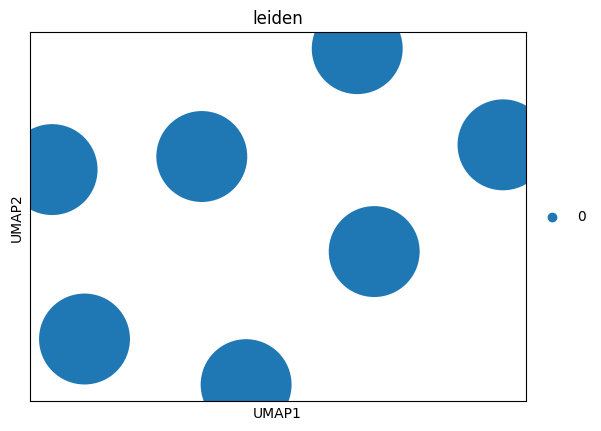

In [50]:
# Use scVI embeddings for UMAP
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5)    # cluster labels

sc.pl.umap(adata, color=["leiden"])    # inspect clusters

In [51]:
# debugging
print(adata.obs.columns.tolist())   # see what annotation columns exist
print(adata.obs['leiden'].value_counts())  # check if leiden clusters were assigned

['n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'leiden']
leiden
0    7
Name: count, dtype: int64


['0']
Categories (1, object): ['0']


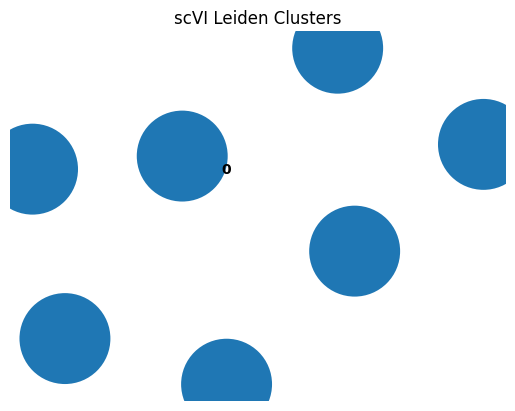

In [52]:
# Confirm the column name exactly as stored
print(adata.obs['leiden'].unique())

# Plot with explicit color mapping
sc.pl.umap(
    adata,
    color='leiden',
    palette='tab10',        # forces distinct colors per cluster
    legend_loc='on data',   # labels each cluster directly on the plot
    frameon=False,
    title='scVI Leiden Clusters'
)

/tmp/ipykernel_10759/357112668.py:13: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5)


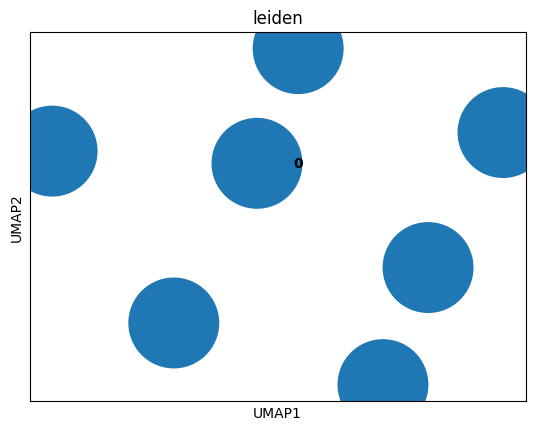

In [53]:
# Step 1: build neighbor graph using scVI embeddings
sc.pp.neighbors(
    adata,
    use_rep="X_scVI",   # critical — must use scVI latent space, not PCA
    n_neighbors=15,
    n_pcs=None          # ignored when use_rep is set
)

# Step 2: compute UMAP
sc.tl.umap(adata, min_dist=0.3)

# Step 3: cluster
sc.tl.leiden(adata, resolution=0.5)

# Step 4: plot
sc.pl.umap(adata, color='leiden', palette='tab10', legend_loc='on data')

Variance per latent dim: [1.9355 2.74   2.6582 3.8533 1.6881 1.3268 0.7191 1.4819 0.449  1.471
 1.8993 0.9659 0.6357 0.7716]


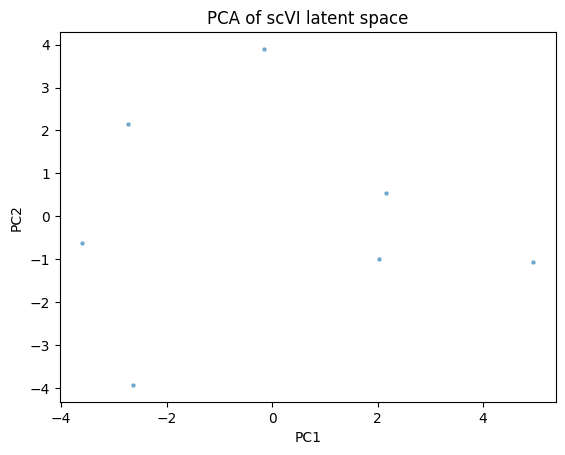

In [55]:
import matplotlib.pyplot as plt
import numpy as np

cell_emb = adata.obsm["X_scVI"]   # shape: (n_cells, 14)

# Check variance across latent dimensions — low variance = collapsed embedding
print("Variance per latent dim:", np.var(cell_emb, axis=0).round(4))

# Quick PCA of the 14-dim embedding to see if there is any separation
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(cell_emb)

plt.scatter(emb_2d[:, 0], emb_2d[:, 1], s=5, alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of scVI latent space")
plt.show()

In [56]:
# Number of cells in dataset

print(adata.shape)   # run this to confirm
# Expected output: (7, n_genes)

(7, 49952)


In [57]:
print(f"Cells: {adata.n_obs}")
print(f"Genes: {adata.n_vars}")
print(adata)

Cells: 7
Genes: 49952
AnnData object with n_obs × n_vars = 7 × 49952
    obs: 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'leiden'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'log1p', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'leiden', 'leiden_colors'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'


# 6. Generate DNA Sequence Embeddings (WGS Input)

## 6a. Align raw WGS FASTQs to reference genome

In [ ]:
%%bash

# Align each cell's WGS FASTQ to GRCh38
bwa mem -t 8 GRCh38.fa {cell}_dna_1.fastq.gz {cell}_dna_2.fastq.gz \
  | samtools sort -o {cell}.bam
samtools index {cell}.bam

## 6b. Define 1 Mb genomic windows

In [ ]:
import pyranges as pr
import pandas as pd

# Define 1 Mb tiling windows across the genome
# Or focus on windows overlapping expressed genes
expressed_genes = adata.var_names[adata.var['highly_variable']]

# Load GTF gene annotations and extract coordinates for expressed genes
# Then create 1Mb windows centered on each gene locus

## 6c. Extract per-cell variant calls

In [ ]:
# For each cell BAM, call variants relative to GRCh38
# Use GATK HaplotypeCaller or bcftools for SNP calls
# Use CNVkit or HMMcopy for CNV calls from sparse coverage

# The reference genome + per-cell variant overlay = your model's DNA input